# Question 2: Algorithm Runtime Analysis from Excel Data

This notebook reads runtime data for three algorithms across different input sizes from `s02.xlsx`, generates bar, line, and box plots, and performs the required analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Read Excel file dynamically (no manual data entry)
excel_path = Path('s02.xlsx')
df = pd.read_excel(excel_path)

# Clean column names and display the full dataset
df.columns = df.columns.str.strip()
print("Columns:", df.columns.tolist())
print("\nFull dataset:")
display(df)

Columns: ['Run time for different data size', 'Alg.1', 'Alg.2', 'Alg.3']

Full dataset:


,Run time for different data size,Alg.1,Alg.2,Alg.3
0,100KB,50,200,100
1,200KB,55,220,200
2,300KB,60,240,300
3,400KB,65,260,400
4,500KB,70,280,500
5,600KB,75,300,600


In [2]:
# Extract column names dynamically from the Excel file
size_col = [c for c in df.columns if 'data size' in c.lower() or 'size' in c.lower()][0]
alg_cols = [c for c in df.columns if c.startswith('Alg.')]

# Parse data size labels (e.g. "100KB") into numeric values in KB
def parse_size(label):
    return int(str(label).strip().upper().replace('KB', ''))

df['Size_KB'] = df[size_col].apply(parse_size)

algorithms = alg_cols
sizes = df['Size_KB'].values
size_labels = df[size_col].astype(str).values

# Keep a copy of the original Excel data (used in part 2c)
df_original = df.copy()

print(f"Size column: '{size_col}'")
print(f"Algorithm columns: {alg_cols}")
print(f"Data sizes (KB): {sizes}")

Size column: 'Run time for different data size'
Algorithm columns: ['Alg.1', 'Alg.2', 'Alg.3']
Data sizes (KB): [100 200 300 400 500 600]


In [3]:
# Plotting functions (reused in parts 2a and 2b without code changes)
colors = ['#4472C4', '#ED7D31', '#70AD47']


def plot_bar_chart(dataframe, title_suffix=''):
    x_pos = np.arange(len(dataframe))
    bar_width = 0.25
    labels = dataframe[size_col].astype(str).values

    fig, ax = plt.subplots(figsize=(12, 6))
    for i, alg in enumerate(algorithms):
        offset = (i - 1) * bar_width
        ax.bar(x_pos + offset, dataframe[alg].values, bar_width, label=alg, color=colors[i])

    ax.set_xlabel('Data Size')
    ax.set_ylabel('Runtime')
    ax.set_title(f'Bar Chart: Algorithm Runtime vs. Data Size{title_suffix}')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_line_chart(dataframe, title_suffix=''):
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, alg in enumerate(algorithms):
        ax.plot(dataframe['Size_KB'].values, dataframe[alg].values,
                marker='o', linewidth=2, markersize=8, label=alg, color=colors[i])

    ax.set_xlabel('Data Size (KB)')
    ax.set_ylabel('Runtime')
    ax.set_title(f'Line Chart: Algorithm Runtime Trends{title_suffix}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_box_chart(dataframe, title_suffix=''):
    runtime_data = [dataframe[alg].values for alg in algorithms]

    fig, ax = plt.subplots(figsize=(10, 6))
    bp = ax.boxplot(runtime_data, labels=algorithms, patch_artist=True)

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    ax.set_xlabel('Algorithm')
    ax.set_ylabel('Runtime')
    ax.set_title(f'Box Plot: Runtime Distribution per Algorithm{title_suffix}')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 2(a) Bar Chart — Runtime Comparison by Data Size

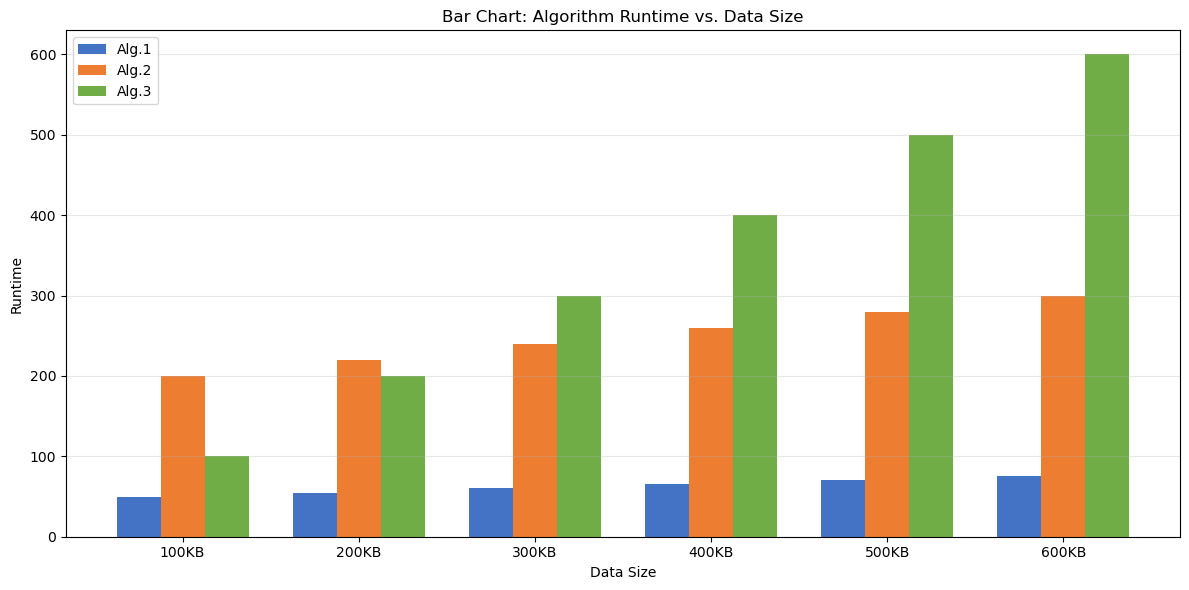

In [4]:
plot_bar_chart(df)

### Bar Chart Analysis

- **Alg.1** shows the lowest runtime across all data sizes, increasing slowly from 50 to 75.
- **Alg.2** has moderate runtime, growing linearly from 200 to 300.
- **Alg.3** has the highest runtime, with values roughly proportional to data size (100 → 600).
- The bar chart clearly shows that **Alg.3 dominates total execution time**, while **Alg.1 is the most efficient** for every input size.
- The gap between algorithms widens as data size increases, especially between Alg.1 and Alg.3.

## 2(a) Line Chart — Runtime Trends

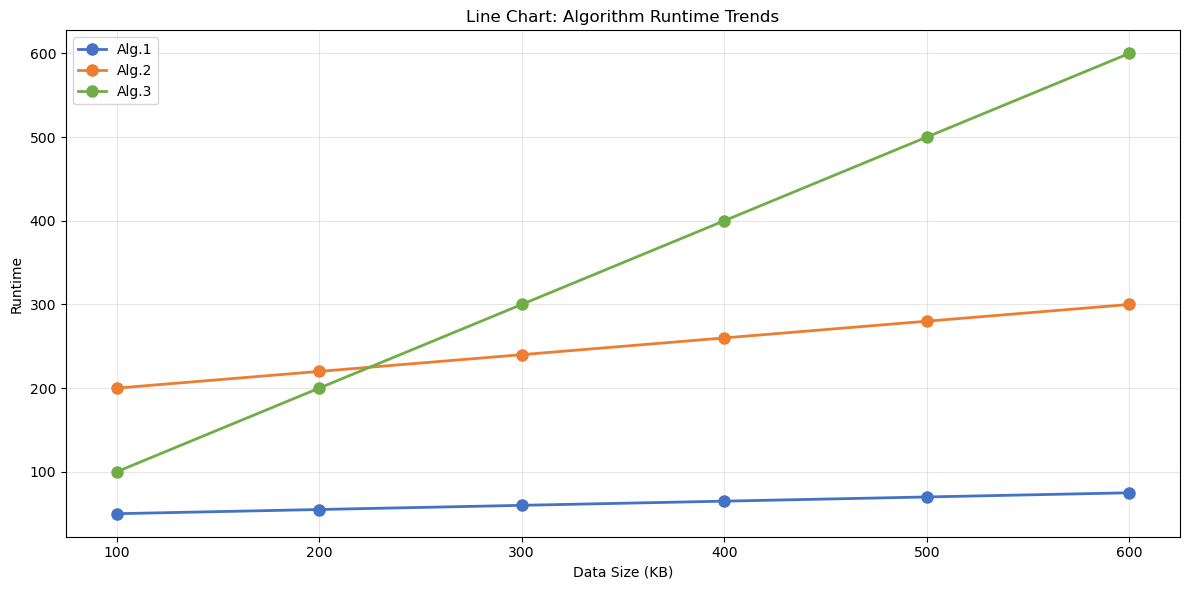

In [5]:
plot_line_chart(df)

### Line Chart Analysis

- All three algorithms exhibit **approximately linear growth** in runtime as data size increases.
- **Alg.3** has the steepest slope (~1 unit runtime per 1 KB), indicating $O(n)$-like scaling with the largest constant factor.
- **Alg.2** has a moderate slope (~0.2 unit per KB increase).
- **Alg.1** has the gentlest slope (~0.05 unit per KB), confirming it scales best with input size.
- The lines are roughly parallel in shape but separated by large constant offsets, suggesting the same complexity class with different constant factors.

## 2(a) Box Plot — Runtime Distribution per Algorithm

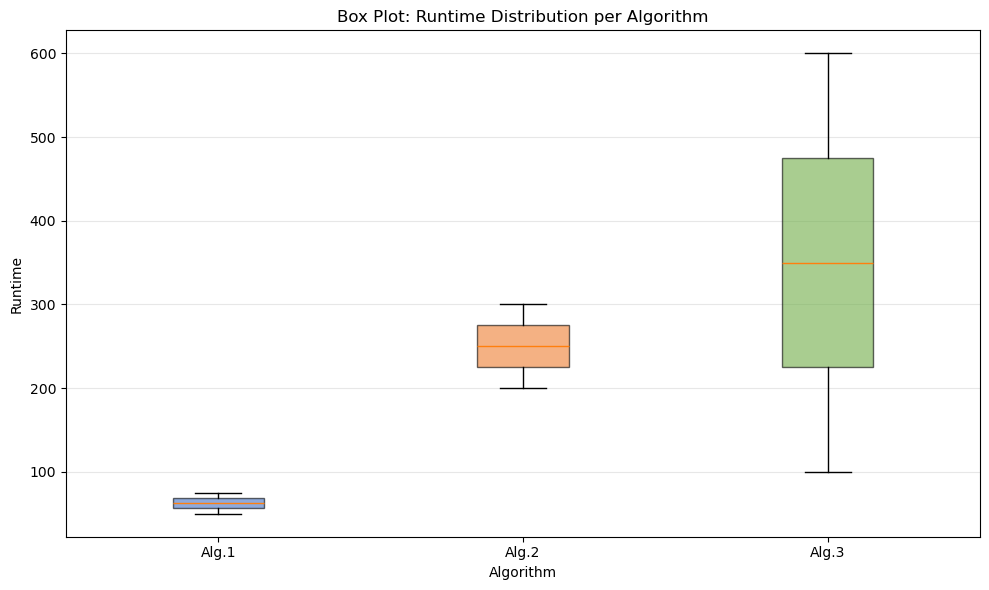

In [6]:
plot_box_chart(df)

### Box Plot Analysis

- **Alg.1** has the lowest median runtime (~62.5) and the smallest interquartile range, indicating consistently fast performance.
- **Alg.2** has a median around 250 with moderate spread.
- **Alg.3** has the highest median (~350) and the widest range (100–600), reflecting its strong dependence on data size.
- No outliers are present since all data points follow a smooth linear trend.
- The box plot confirms the ranking: **Alg.1 < Alg.2 < Alg.3** in terms of both central tendency and overall spread.

## 2(b) Adding New Data Row Programmatically

The following new row is created as a variable and appended to the dataset read from Excel:

| Data size | Alg.1 | Alg.2 | Alg.3 |
|-----------|-------|-------|-------|
| 700KB     | 80    | 320   | 700   |

After appending, the same plotting code from part 2(a) is executed again on the updated data — no changes to the plotting functions are required.

In [7]:
# Create the new data row and append it to the existing dataset
new_row = {
    size_col: '700KB',
    'Alg.1': 80,
    'Alg.2': 320,
    'Alg.3': 700,
}

df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
df['Size_KB'] = df[size_col].apply(parse_size)

# Update helper variables used by the plotting functions
sizes = df['Size_KB'].values
size_labels = df[size_col].astype(str).values

print("Updated dataset after adding the new row:")
display(df)

Updated dataset after adding the new row:


,Run time for different data size,Alg.1,Alg.2,Alg.3,Size_KB
0,100KB,50,200,100,100
1,200KB,55,220,200,200
2,300KB,60,240,300,300
3,400KB,65,260,400,400
4,500KB,70,280,500,500
5,600KB,75,300,600,600
6,700KB,80,320,700,700


### Updated Charts (after adding 700 KB row)

The same plotting functions from part 2(a) are re-run on the updated dataset:

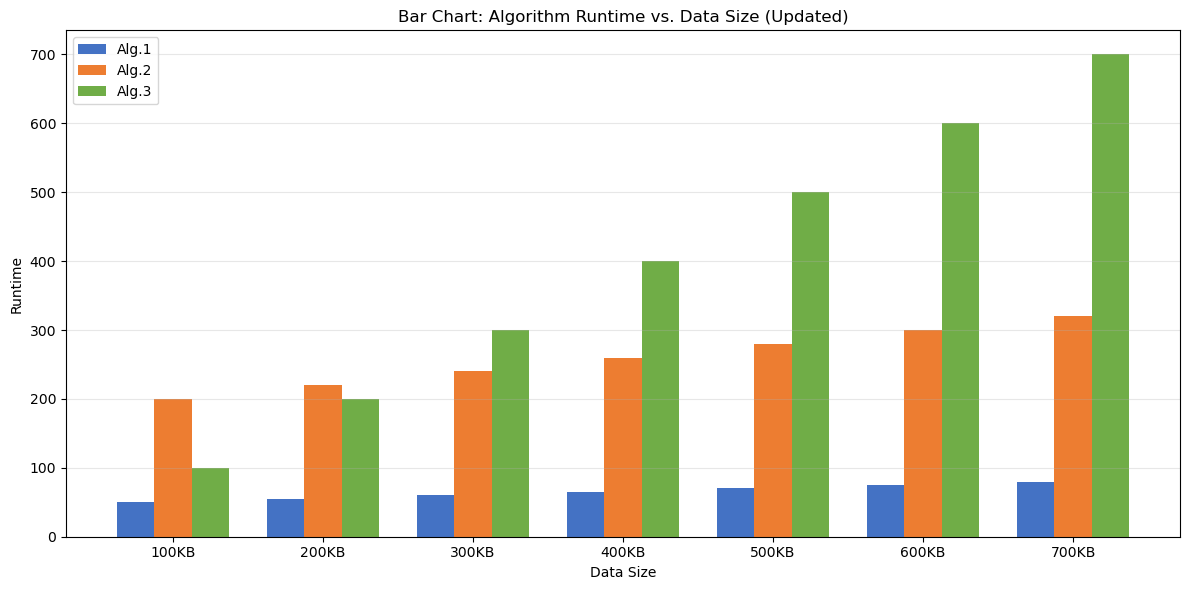

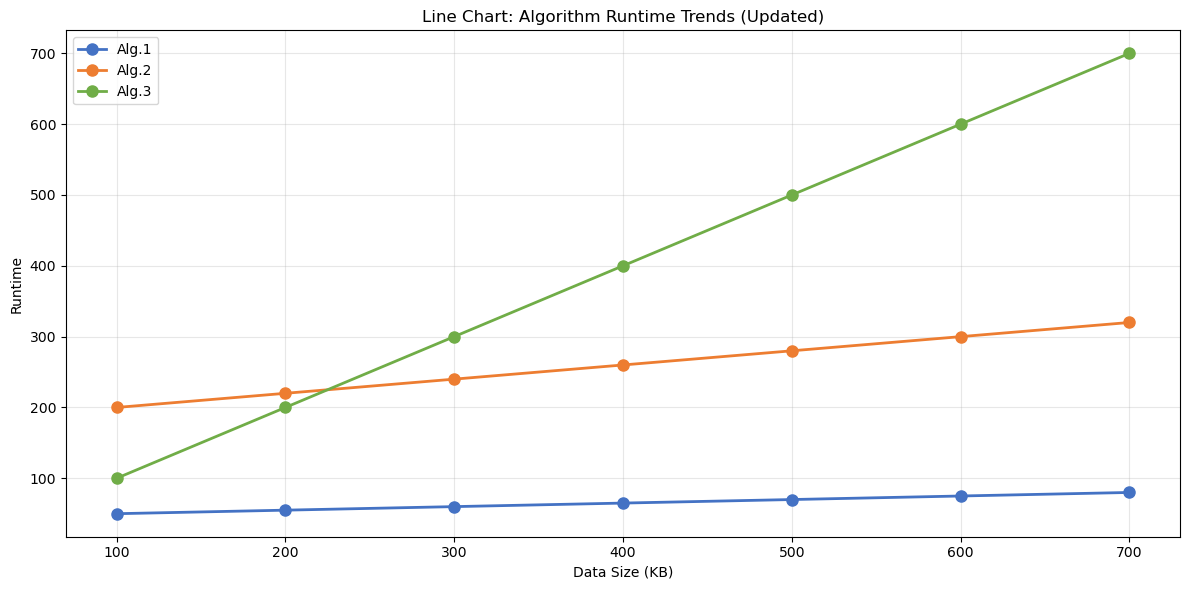

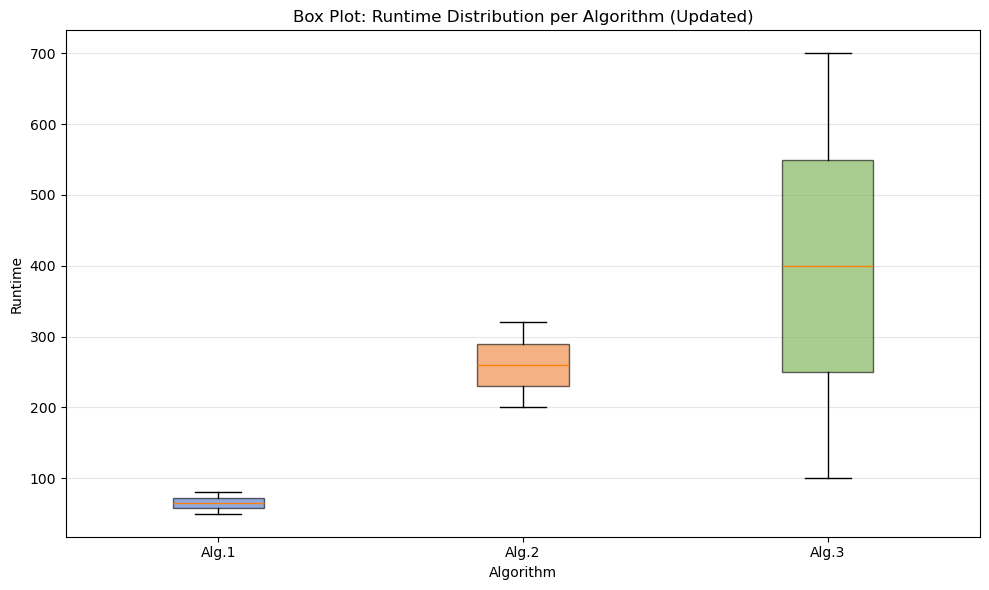

In [8]:
# Re-run the same plotting code on the updated data (no code changes needed)
plot_bar_chart(df, title_suffix=' (Updated)')
plot_line_chart(df, title_suffix=' (Updated)')
plot_box_chart(df, title_suffix=' (Updated)')

### Updated Charts Analysis

- After adding the **700 KB** row, all three charts automatically include the new data point.
- **Alg.1** runtime increases to 80, **Alg.2** to 320, and **Alg.3** to 700 at 700 KB.
- The linear trends observed in part 2(a) continue with the new point, confirming consistent scaling behavior.
- The updated box plot shows a wider range for Alg.3 (100–700), while Alg.1 and Alg.2 maintain their relative positions.

## 2(c) Mean Runtime of Algorithm 2 (100 KB – 600 KB)

In [9]:
# Filter data for sizes 100 KB to 600 KB only (use original Excel data)
mask = (df_original['Size_KB'] >= 100) & (df_original['Size_KB'] <= 600)
df_filtered = df_original[mask]

alg2_col = [c for c in df_original.columns if 'Alg.2' in c][0]
mean_alg2 = df_filtered[alg2_col].mean()

print(f"Algorithm 2 column: '{alg2_col}'")
print(f"\nData used (100 KB – 600 KB):")
display(df_filtered[[size_col, alg2_col]])

print(f"\nMean runtime of Algorithm 2 (100–600 KB): {mean_alg2:.2f}")

Algorithm 2 column: 'Alg.2'

Data used (100 KB – 600 KB):


,Run time for different data size,Alg.2
0,100KB,200
1,200KB,220
2,300KB,240
3,400KB,260
4,500KB,280
5,600KB,300



Mean runtime of Algorithm 2 (100–600 KB): 250.00
